In [1]:
# Task 1: Data Preparation
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define URL and column names based on UCI Credit Approval dataset schema
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/credit-screening/crx.data"
columns = [f"A{i}" for i in range(1, 16)] + ["Target"]

# Load data, replacing missing value representations ('?') with NaN
df = pd.read_csv(url, names=columns, na_values="?")

# Export dataset to CSV format for local persistence
df.to_csv("credit_approval_raw.csv", index=False)
print("Data Preparation Complete. Shape:", df.shape)
df.head()

Data Preparation Complete. Shape: (690, 16)


,A1,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,Target
0,b,30.83,0.000,u,g,w,v,1.25,t,t,1,f,g,202.0,0,+
1,a,58.67,4.460,u,g,q,h,3.04,t,t,6,f,g,43.0,560,+
2,a,24.50,0.500,u,g,q,h,1.50,t,f,0,f,g,280.0,824,+
3,b,27.83,1.540,u,g,w,v,3.75,t,t,5,t,g,100.0,3,+
4,b,20.17,5.625,u,g,w,v,1.71,t,f,0,f,s,120.0,0,+


Missing Values Summary:
 A1     12
A2     12
A4      6
A5      6
A6      9
A7      9
A14    13
dtype: int64


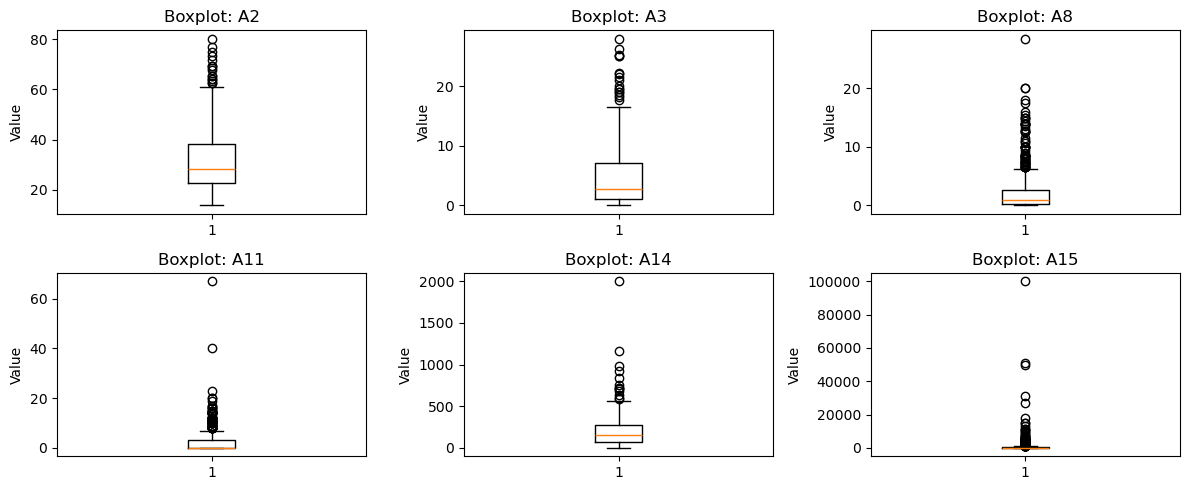

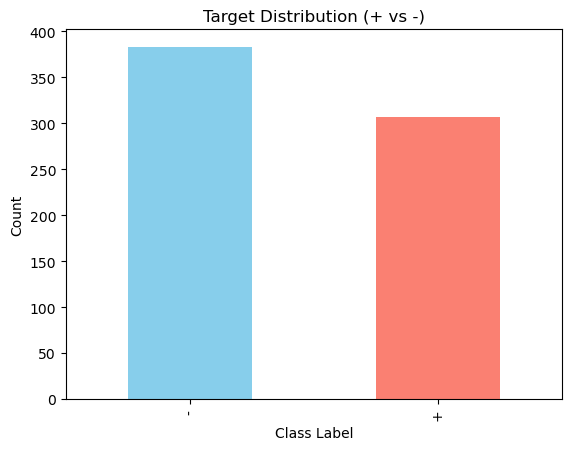

In [2]:
# Task 2: Exploratory Data Analysis (EDA)
missing_summary = df.isnull().sum()
print("Missing Values Summary:\n", missing_summary[missing_summary > 0])

num_cols = df.select_dtypes(include=[np.number]).columns

plt.figure(figsize=(12, 5))
for i, col in enumerate(num_cols, 1):
    plt.subplot(2, 3, i)
    plt.boxplot(df[col].dropna())
    plt.title(f"Boxplot: {col}")
    plt.ylabel("Value")

plt.tight_layout()
plt.show()

df['Target'].value_counts().plot(kind='bar', color=['skyblue', 'salmon'])
plt.title("Target Distribution (+ vs -)")
plt.xlabel("Class Label")
plt.ylabel("Count")
plt.show()

In [5]:
# Task 3: Preprocessing, Feature Selection & Engineering
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler

df_proc = df.copy()


for col in num_cols:
    Q1 = df_proc[col].quantile(0.25)
    Q3 = df_proc[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df_proc[col] = np.clip(df_proc[col], lower_bound, upper_bound)


num_imputer = SimpleImputer(strategy='median')
cat_imputer = SimpleImputer(strategy='most_frequent')

cat_cols = df_proc.select_dtypes(include=['object']).columns.drop('Target')

df_proc[num_cols] = num_imputer.fit_transform(df_proc[num_cols])
df_proc[cat_cols] = cat_imputer.fit_transform(df_proc[cat_cols])


le = LabelEncoder()
for col in cat_cols:
    df_proc[col] = le.fit_transform(df_proc[col])

df_proc['Target'] = le.fit_transform(df_proc['Target']) # binary 0/1 encoding


X = df_proc.drop('Target', axis=1)
y = df_proc['Target']

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)


pd.concat([X_scaled, y], axis=1).to_csv("credit_approval_preprocessed.csv", index=False)
print("Preprocessing Complete.")

Preprocessing Complete.


In [ ]:
# Task 4: Model Creation & Evaluation

from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score


X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42, stratify=y)


base_model = LogisticRegression(random_state=42)
base_model.fit(X_train, y_train)
y_pred_base = base_model.predict(X_test)

base_acc = accuracy_score(y_test, y_pred_base)
base_f1 = f1_score(y_test, y_pred_base)

print(f"--- 4a: Baseline Model Results ---")
print(f"Accuracy: {base_acc:.4f} | F1-Score: {base_f1:.4f}\n")


cv_stratified = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

mlp = MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42)
scoring = ['accuracy', 'f1']

mlp_cv_results = cross_validate(mlp, X_scaled, y, cv=cv_stratified, scoring=scoring)

mlp_cv_acc = mlp_cv_results['test_accuracy'].mean()
mlp_cv_f1 = mlp_cv_results['test_f1'].mean()

print(f"--- 4b: Multi-layer Neural Network (10-Fold CV) ---")
print(f"Mean Accuracy: {mlp_cv_acc:.4f} | Mean F1-Score: {mlp_cv_f1:.4f}\n")


param_grid = {
    'hidden_layer_sizes': [(32, 16), (64, 32)],
    'activation': ['relu', 'tanh'],
    'learning_rate_init': [0.001, 0.01],
    'alpha': [0.0001, 0.01]  
}

grid_search = GridSearchCV(
    estimator=MLPClassifier(max_iter=500, random_state=42),
    param_grid=param_grid,
    cv=cv_stratified,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_scaled, y)
best_mlp = grid_search.best_estimator_


tuned_cv_results = cross_validate(best_mlp, X_scaled, y, cv=cv_stratified, scoring=scoring)
tuned_cv_acc = tuned_cv_results['test_accuracy'].mean()
tuned_cv_f1 = tuned_cv_results['test_f1'].mean()

print(f"--- 4c: Hyperparameter Tuning Results ---")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Tuned MLP Mean CV Accuracy: {tuned_cv_acc:.4f} | Tuned MLP Mean CV F1-Score: {tuned_cv_f1:.4f}\n")


models = ['Baseline (Logistic Reg)', 'Default MLP (10-Fold)', 'Tuned MLP (10-Fold)']
accuracies = [base_acc, mlp_cv_acc, tuned_cv_acc]
f1_scores = [base_f1, mlp_cv_f1, tuned_cv_f1]

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
rects1 = ax.bar(x - width/2, accuracies, width, label='Accuracy', color='royalblue')
rects2 = ax.bar(x + width/2, f1_scores, width, label='F1-Score', color='darkorange')

ax.set_ylabel('Scores')
ax.set_title('Model Performance Comparison')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.set_ylim(0, 1.0)
ax.legend()


for rect in rects1 + rects2:
    height = rect.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(rect.get_x() + rect.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points",
                ha='center', va='bottom')

plt.tight_layout()
plt.show()

--- 4a: Baseline Model Results ---
Accuracy: 0.7971 | F1-Score: 0.8108

